# Tutorial 15-3: Pixel Player – "Convolutional DQN for Atari"

**Course:** CSEN 342: Deep Learning  
**Topic:** Deep Reinforcement Learning, CNNs, and Frame Stacking

## Objective
In the previous tutorial, we solved CartPole using numerical inputs (position, velocity). But for video games like **Atari**, the agent only sees the screen pixels. It must learn to "see" the ball and paddle before it can learn to play.

In this tutorial, we will build the **Deep Q-Network (DQN)** architecture used by DeepMind to solve Atari games (Mnih et al., 2013/2015).

We will implement:
1.  **Preprocessing:** Convert raw $210 \times 160$ RGB images into $84 \times 84$ Grayscale blocks.
2.  **Frame Stacking:** Stack 4 consecutive frames so the agent can perceive motion (velocity/direction).
3.  **The CNN:** Build the convolutional architecture specified in the lecture slides .

**Note:** Training an Atari agent takes millions of steps (hours/days). This tutorial focuses on **building the architecture** and verifying the data pipeline. Run this tutorial in the `Transformers Bundle` kernel.

---

## Part 1: Setup and Raw Environment

We use `gymnasium` with the `ale-py` provider. We will play **Pong** (`PongNoFrameskip-v4`).

In [1]:
# Run if necessary
!python -m pip install --user gymnasium[atari] ale-py

Using device: cuda


A.L.E: Arcade Learning Environment (version 0.8.1+53f58b7)
[Powered by Stella]


Raw State Shape: (210, 160, 3)


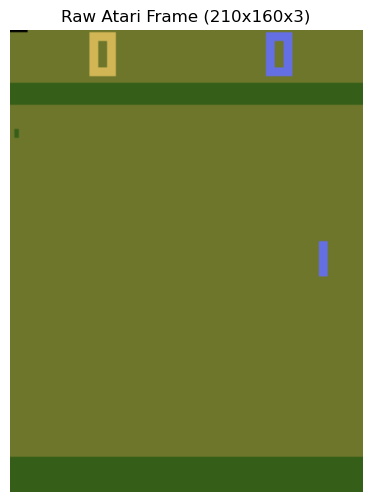

In [2]:
import gymnasium as gym
import subprocess
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2
from collections import deque

def setup_atari(env_id = "ALE/Pong-v5"):
    try:
        # Try to import ale_py to check if the package exists
        import ale_py
    except ImportError:
        print("ale-py not found. Installing Atari dependencies...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "gymnasium[atari]", "ale-py"])

    # Attempt to create the environment
    try:
        return gym.make(env_id, render_mode="rgb_array")
    except (gym.error.NameNotFound, gym.error.NamespaceNotFound):
        print("ROMs or Namespace missing. Running AutoROM...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "autorom[accept-rom-license]"])
        subprocess.run(["AutoROM", "--accept-license"])
        # Re-import/initialize after installation
        return gym.make(env_id, render_mode="rgb_array")


# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

env = setup_atari()
state, _ = env.reset()
print(f"Raw State Shape: {state.shape}")

# Visualize Raw Frame
plt.figure(figsize=(6, 6))
plt.imshow(state)
plt.title("Raw Atari Frame (210x160x3)")
plt.axis('off')
plt.show()

---

## Part 2: The Preprocessing Pipeline

The raw image is too big ($210 \times 160 \times 3 \approx 100k$ values). We need to shrink it.

**Steps (Slide 45):**
1.  **Grayscale:** Color doesn't matter in Pong.
2.  **Resize:** Downsample to $84 \times 84$.
3.  **Stack:** Combine the last 4 frames into a single input tensor of shape $(4, 84, 84)$. This allows the CNN to see *speed* and *direction*.

We implement this as a Wrapper.

Processed State Shape: (4, 84, 84)


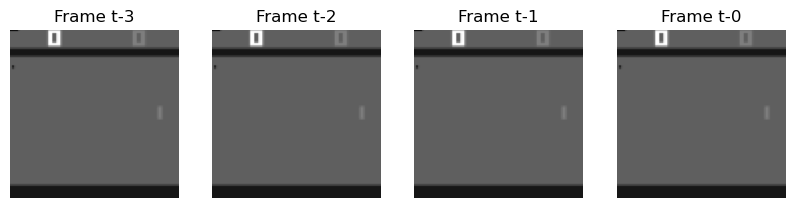

In [3]:
class AtariPreprocess(gym.Wrapper):
    def __init__(self, env, k=4):
        super(AtariPreprocess, self).__init__(env)
        self.k = k # Number of frames to stack
        # Queue to store the last k frames
        self.frames = deque([], maxlen=k)
        
        # Define new observation space: (4, 84, 84)
        self.observation_space = gym.spaces.Box(
            low=0, high=255, shape=(k, 84, 84), dtype=np.uint8
        )

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        processed = self.process_frame(obs)
        # Fill buffer with the first frame duplicated k times
        for _ in range(self.k):
            self.frames.append(processed)
        return self._get_obs(), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.frames.append(self.process_frame(obs))
        return self._get_obs(), reward, terminated, truncated, info

    def _get_obs(self):
        # Stack frames: List of (84, 84) -> (4, 84, 84)
        return np.array(list(self.frames))

    def process_frame(self, frame):
        # 1. Grayscale (using OpenCV)
        gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
        # 2. Resize to 84x84
        resized = cv2.resize(gray, (84, 84), interpolation=cv2.INTER_AREA)
        return resized

# Wrap the environment
env_processed = AtariPreprocess(env, k=4)
state, _ = env_processed.reset()

print(f"Processed State Shape: {state.shape}")

# Visualize the stack
plt.figure(figsize=(10, 3))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(state[i], cmap='gray')
    plt.title(f"Frame t-{3-i}")
    plt.axis('off')
plt.show()

---

## Part 3: The Convolutional Q-Network

We implement the architecture defined in **Slide 47**  (NIPS 2013 version).

* **Input:** $4 \times 84 \times 84$
* **Conv1:** 16 filters, kernel $8 \times 8$, stride 4. Activation: ReLU.
* **Conv2:** 32 filters, kernel $4 \times 4$, stride 2. Activation: ReLU.
* **Flatten:** Convert feature maps to vector.
* **FC1:** 256 units. Activation: ReLU.
* **Output:** $N_{actions}$ units (Q-values).

In [4]:
class DQN(nn.Module):
    def __init__(self, input_shape, num_actions):
        super(DQN, self).__init__()
        # input_shape is (4, 84, 84)
        
        # Conv 1: 16 filters, 8x8, stride 4
        self.conv1 = nn.Conv2d(input_shape[0], 16, kernel_size=8, stride=4)
        
        # Conv 2: 32 filters, 4x4, stride 2
        self.conv2 = nn.Conv2d(16, 32, kernel_size=4, stride=2)
        
        # Calculate size of flattened features
        def conv2d_size_out(size, kernel_size, stride):
            return (size - (kernel_size - 1) - 1) // stride + 1
        
        h, w = input_shape[1], input_shape[2]
        h = conv2d_size_out(h, 8, 4) # After Conv1
        w = conv2d_size_out(w, 8, 4)
        h = conv2d_size_out(h, 4, 2) # After Conv2
        w = conv2d_size_out(w, 4, 2)
        linear_input_size = h * w * 32
        
        # Fully Connected Layers
        self.fc1 = nn.Linear(linear_input_size, 256)
        self.fc2 = nn.Linear(256, num_actions)

    def forward(self, x):
        # Normalize pixel values to [0, 1]
        x = x / 255.0
        
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# Initialize Model
input_shape = env_processed.observation_space.shape
n_actions = env_processed.action_space.n

policy_net = DQN(input_shape, n_actions).to(device)
print(policy_net)

# Test Forward Pass with dummy data
dummy_input = torch.zeros(1, *input_shape).to(device)
output = policy_net(dummy_input)
print(f"\nOutput Q-values shape: {output.shape} (Batch, Actions)")

DQN(
  (conv1): Conv2d(4, 16, kernel_size=(8, 8), stride=(4, 4))
  (conv2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2))
  (fc1): Linear(in_features=2592, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=6, bias=True)
)

Output Q-values shape: torch.Size([1, 6]) (Batch, Actions)


---

## Part 4: The Agent Loop (Untrained)

Let's run the agent in the environment. Since we haven't trained it (which takes days), it will act randomly. However, this verifies that our Preprocessing -> CNN -> Action selection pipeline works correctly.

We will perform an **Epsilon-Greedy** selection using the network.

In [5]:
import random

def select_action(state, epsilon=0.1):
    # state: (4, 84, 84) numpy array
    if random.random() < epsilon:
        return env.action_space.sample() # Explore
    else:
        with torch.no_grad():
            # Convert to tensor and add batch dim: (1, 4, 84, 84)
            state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            q_values = policy_net(state_t)
            return q_values.argmax().item() # Exploit

# Run one episode
state, _ = env_processed.reset()
done = False
total_reward = 0
steps = 0

print("Running inference loop...")
while not done and steps < 200: # Limit steps for speed
    action = select_action(state, epsilon=0.1)
    next_state, reward, terminated, truncated, _ = env_processed.step(action)
    done = terminated or truncated
    
    state = next_state
    total_reward += reward
    steps += 1
    
    if steps % 50 == 0:
        print(f"Step {steps}: Action {action}, Reward {reward}")

print(f"Episode Finished. Total Reward: {total_reward}")

Running inference loop...
Step 50: Action 0, Reward 0.0
Step 100: Action 2, Reward 0.0
Step 150: Action 2, Reward 0.0
Step 200: Action 2, Reward 0.0
Episode Finished. Total Reward: -4.0


### Conclusion

You have successfully built the **"Eyes"** and **"Brain"** of an Atari-playing agent!

1.  **Preprocessing:** You shrunk the data by ~90% (210x160x3 -> 4x84x84) while preserving temporal information (frame stacking).
2.  **CNN:** You implemented the specific convolutional architecture used in the breakthrough RL papers.
3.  **Inference:** You connected the environment to the network.

To solve the game, you would now wrap this in the **Replay Buffer** and **Target Network** loop from Tutorial 15-2 and let it run for ~10 million frames.